In [71]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import optuna

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score, f1_score, brier_score_loss
from sklearn.preprocessing import StandardScaler, label_binarize, LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression

import xgboost as xgb

from itertools import product

pd.set_option('display.max_rows', 1000)

In [72]:
data = pd.read_excel("database_from_Bitcointalk.xlsx")
len(data)

4684

In [73]:
data = data[data["total"]>=15]
len(data)

1942

In [74]:
data.columns = data.columns.astype(str)
data.head()

,entity,region,0,1,2,3,4,5,6,7,...,16,17,18,19,20,21,22,23,total,log_total
0,Entity 0,Central_Asia,0.025191,0.043089,0.042095,0.049718,0.030162,0.050713,0.034803,0.063971,...,0.034803,0.036460,0.013590,0.030162,0.014584,0.033477,0.043752,0.036460,2993,8.004032
1,Entity 1,East_Asia_Pac,0.006951,0.020854,0.065541,0.069513,0.077458,0.045680,0.049652,0.060576,...,0.041708,0.035750,0.005958,0.008937,0.009930,0.006951,0.005958,0.007944,983,6.890609
2,Entity 10,Euro_Africa,0.064461,0.054147,0.052858,0.033090,0.026214,0.027503,0.018049,0.015900,...,0.056725,0.061023,0.053717,0.058444,0.061453,0.055866,0.067039,0.066609,2303,7.741968
3,Entity 100,East_Asia_Pac,0.008368,0.020921,0.029289,0.025105,0.029289,0.071130,0.025105,0.062762,...,0.058577,0.066946,0.112971,0.058577,0.025105,0.008368,0.020921,0.008368,215,5.370638
4,Entity 1000,Euro_Africa,0.035714,0.107143,0.107143,0.053571,0.053571,0.017857,0.035714,0.053571,...,0.017857,0.017857,0.035714,0.017857,0.017857,0.035714,0.035714,0.017857,32,3.465736


In [75]:
X = data
y = data["region"]
col_names = ["0", "1", "2", "3", "4", "5", "6", "7", "8", "9", "10", "11", "12", "13", "14", "15", "16", "17", "18", "19", "20", "21", "22", "23"]

# Logistic regression

In [6]:
num = 7736
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify = y, random_state = num)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[col_names])
X_test_scaled = scaler.transform(X_test[col_names])
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

In [7]:
model = LogisticRegression(  
    class_weight = "balanced",
    max_iter=1000
)
model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [8]:
labels = model.classes_
y_train_pred = model.predict(X_train_scaled)
y_train_proba = model.predict_proba(X_train_scaled)

y_test_pred = model.predict(X_test_scaled)
y_test_proba = model.predict_proba(X_test_scaled)

## Classification metrics

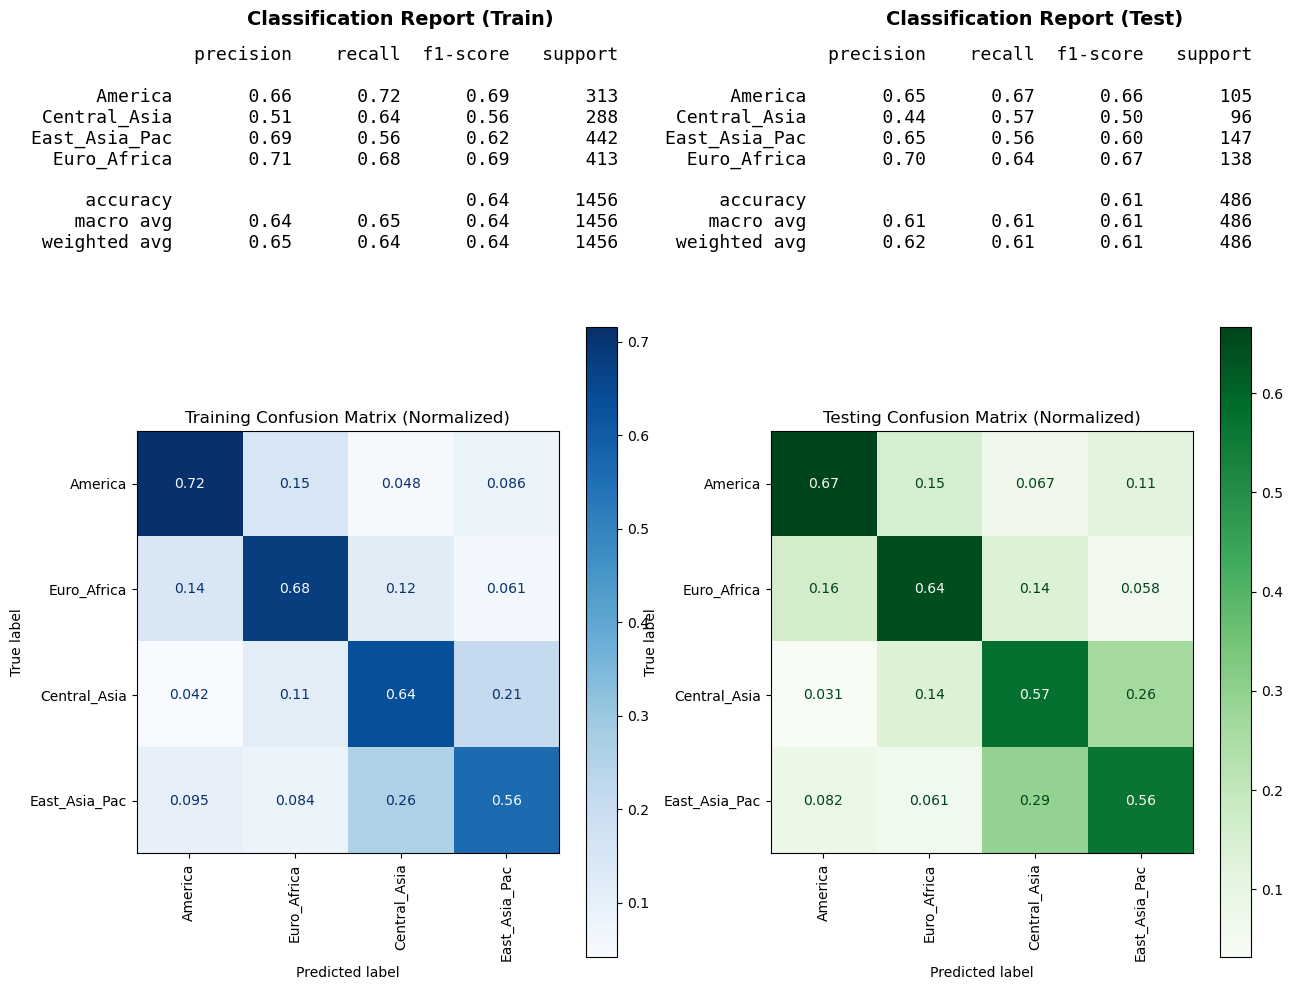

In [9]:
target_names = ["America", "Euro_Africa", "Central_Asia", "East_Asia_Pac"]
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 12), 
                         gridspec_kw={'height_ratios': [0.5, 1.5]})

#Train classification report
axes[0, 0].text(-0.2, 0.4, classification_report(y_train, y_train_pred, target_names = labels), 
                fontsize=13, family='monospace', va='center')
axes[0, 0].set_title("Classification Report (Train)", fontsize=14, fontweight='bold')
axes[0, 0].axis('off') 

#Test classification report
axes[0, 1].text(-0.2, 0.4, classification_report(y_test, y_test_pred, target_names = labels), 
                fontsize=13, family='monospace', va='center')
axes[0, 1].set_title("Classification Report (Test)", fontsize=14, fontweight='bold')
axes[0, 1].axis('off') 

# Train Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_train, y_train_pred, 
    ax=axes[1, 0], cmap='Blues', normalize='true',
    labels = target_names
)
axes[1, 0].set_title("Training Confusion Matrix (Normalized)")
axes[1, 0].tick_params(axis='x', rotation=90)

# Test Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_pred, 
    ax=axes[1, 1], cmap='Greens', normalize='true',
    labels = target_names
)
axes[1, 1].set_title("Testing Confusion Matrix (Normalized)")
axes[1, 1].tick_params(axis='x', rotation=90)

plt.show()

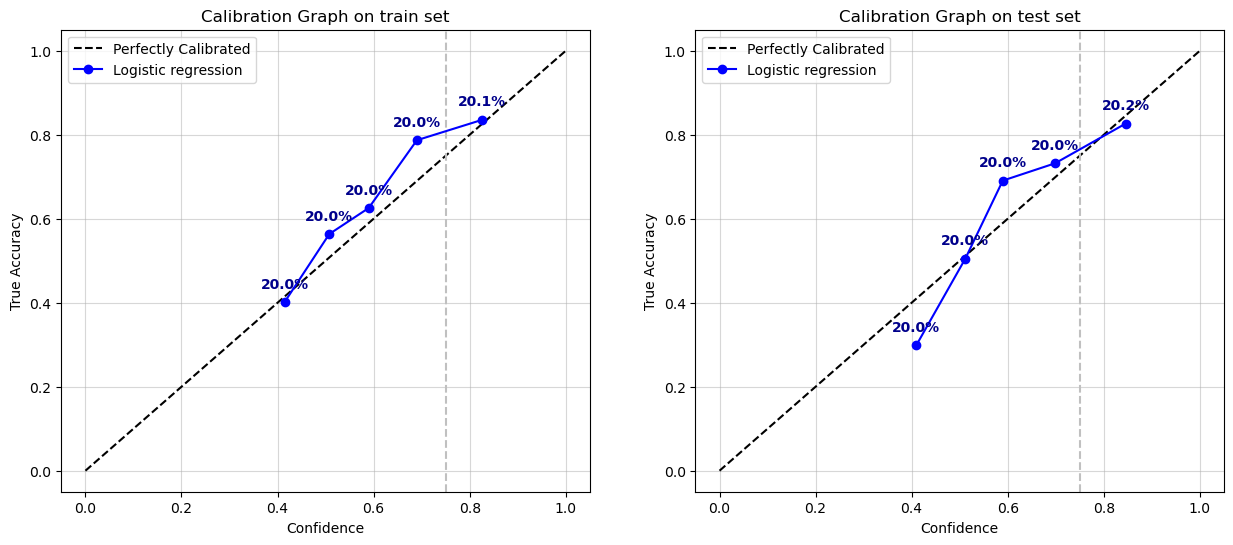

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

for j, l in zip(range(2), ["train", "test"]):
    ax[j].plot([0, 1], [0, 1], "k--", label="Perfectly Calibrated")
    ax[j].plot([0.75, 0.75], [-0.05, 1.05], "--", color = "#C0C0C0")

    proba = locals()[f"y_{l}_proba"]
    pred  = locals()[f"y_{l}_pred"]
    true  = locals()[f"y_{l}"]
    
    confidences = np.max(proba, axis=1)
    accuracies = (pred == true).astype(int)
    n_bins = 5
    percentiles = np.linspace(0.0, 1.0, n_bins + 1)
    bins = np.quantile(confidences, percentiles)
    bin_indices = np.digitize(confidences, bins) - 1
    bin_indices[bin_indices == n_bins] = n_bins - 1
    
    bin_accuracies = []
    bin_confidences = []
    bin_percentages = []
    
    for i in range(n_bins):
        mask = (bin_indices == i)
        if np.sum(mask) > 0: # Ak sú v bine nejaké dáta
            bin_accuracies.append(np.mean(accuracies[mask]))
            bin_confidences.append(np.mean(confidences[mask]))
            bin_percentages.append((np.sum(mask) / len(confidences)) * 100)
    
    ax[j].plot(bin_confidences, bin_accuracies, "bo-", label="Logistic regression")
    
    for b, v, perc in zip(bin_confidences, bin_accuracies, bin_percentages):
        ax[j].annotate(f"{perc:.1f}%", 
                     (b, v), 
                     textcoords="offset points", 
                     xytext=(0, 10), 
                     ha='center',
                     fontsize=10,
                     color="darkblue",
                     fontweight="bold")
    
    ax[j].set_xlabel("Confidence")
    ax[j].set_ylabel("True Accuracy")
    ax[j].set_title(f"Calibration Graph on {l} set")
    ax[j].legend(loc="upper left")
    ax[j].grid(True, alpha=0.5)
    ax[j].set_xlim([-0.05, 1.05])
    ax[j].set_ylim([-0.05, 1.05])

plt.show()

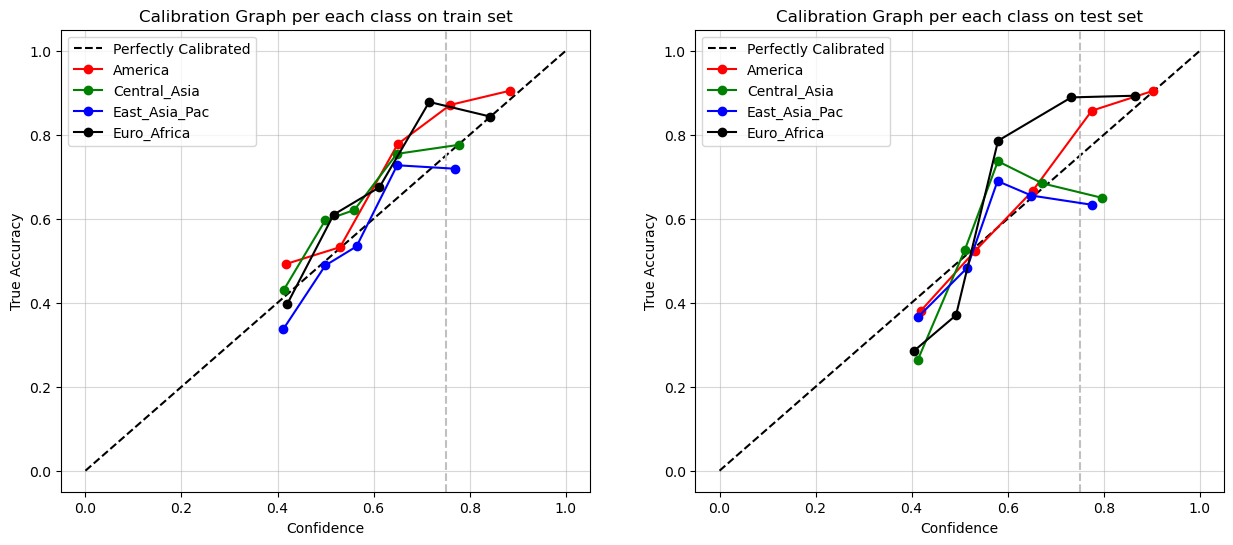

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
colors = ['red', 'green', 'blue', 'black']

for j, a in zip(range(2), ["train", "test"]):
    ax[j].plot([0, 1], [0, 1], "k--", label="Perfectly Calibrated")
    ax[j].plot([0.75, 0.75], [-0.05, 1.05], "--", color = "#C0C0C0")
    for l, c in zip(labels, colors):
        proba = locals()[f"y_{a}_proba"]
        pred  = locals()[f"y_{a}_pred"]
        true  = locals()[f"y_{a}"]
    
        subset = (true == l)
        
        confidences = np.max(proba[subset], axis=1)
        accuracies = (pred[subset] == true[subset]).astype(int)
        n_bins = 5
        percentiles = np.linspace(0.0, 1.0, n_bins + 1)
        bins = np.quantile(confidences, percentiles)
        bin_indices = np.digitize(confidences, bins) - 1
        bin_indices[bin_indices == n_bins] = n_bins - 1
        
        bin_accuracies = []
        bin_confidences = []
        bin_percentages = []
        
        for i in range(n_bins):
            mask = (bin_indices == i)
            if np.sum(mask) > 0: # Ak sú v bine nejaké dáta
                bin_accuracies.append(np.mean(accuracies[mask]))
                bin_confidences.append(np.mean(confidences[mask]))
                bin_percentages.append((np.sum(mask) / len(confidences)) * 100)
    
        ax[j].plot(bin_confidences, bin_accuracies, marker = 'o', linestyle = '-', color=c, label=l)
    
    
    
    ax[j].set_xlabel("Confidence")
    ax[j].set_ylabel("True Accuracy")
    ax[j].set_title(f"Calibration Graph per each class on {a} set")
    ax[j].legend(loc="upper left")
    ax[j].grid(True, alpha=0.5)
    ax[j].set_xlim([-0.05, 1.05])
    ax[j].set_ylim([-0.05, 1.05])

plt.show()

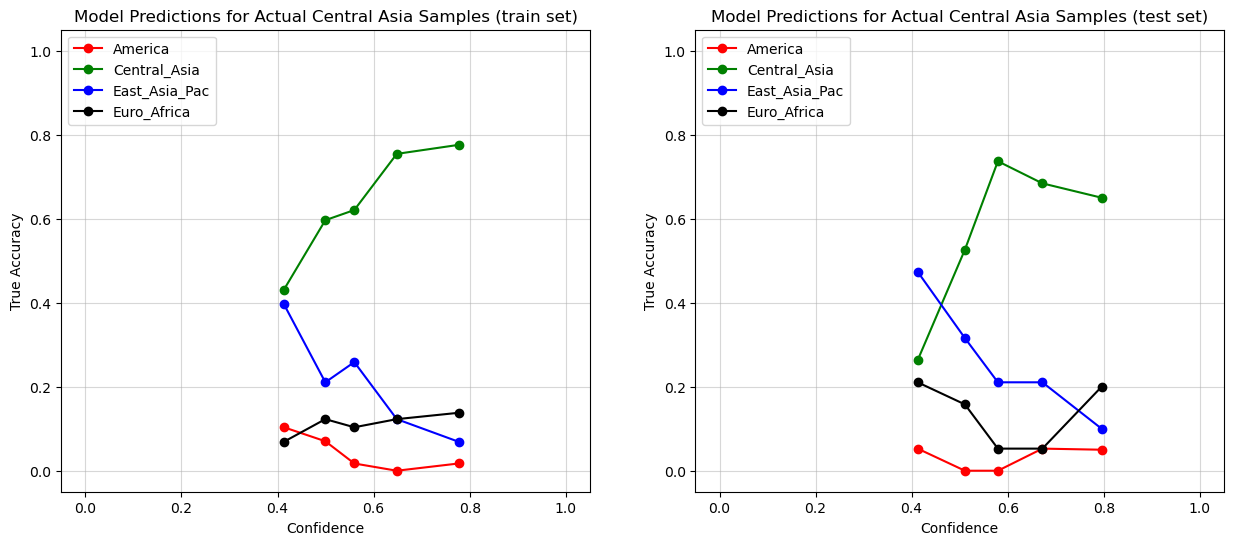

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
colors = ['red', 'green', 'blue', 'black']
for j, a in zip(range(2), ["train", "test"]):
    for l,c in zip(labels, colors):
        proba = locals()[f"y_{a}_proba"]
        pred  = locals()[f"y_{a}_pred"]
        true  = locals()[f"y_{a}"]
    
        subset = (true == "Central_Asia")
        
        confidences = np.max(proba[subset], axis=1)
        accuracies = (pred[subset] == l).astype(int)
        n_bins = 5
        percentiles = np.linspace(0.0, 1.0, n_bins + 1)
        try:
            bins = np.quantile(confidences, percentiles)
            bin_indices = np.digitize(confidences, bins) - 1
            bin_indices[bin_indices == n_bins] = n_bins - 1
            
            bin_accuracies = []
            bin_confidences = []
            bin_percentages = []
            
            # Výpočet priemernej istoty, presnosti a percenta dát pre každý bin
            for i in range(n_bins):
                mask = (bin_indices == i)
                if np.sum(mask) > 0: # Ak sú v bine nejaké dáta
                    bin_accuracies.append(np.mean(accuracies[mask]))
                    bin_confidences.append(np.mean(confidences[mask]))
                    bin_percentages.append((np.sum(mask) / len(confidences)) * 100)
        
            # Tvoja krivka modelu
            ax[j].plot(bin_confidences, bin_accuracies, marker = 'o', linestyle = '-', color=c, label=l)
        except Exception as e:
            continue
        
    
    
    ax[j].set_xlabel("Confidence")
    ax[j].set_ylabel("True Accuracy")
    ax[j].set_title(f"Model Predictions for Actual Central Asia Samples ({a} set)")
    ax[j].legend(loc="upper left")
    ax[j].grid(True, alpha=0.5)
    ax[j].set_xlim([-0.05, 1.05])
    ax[j].set_ylim([-0.05, 1.05])

plt.show()

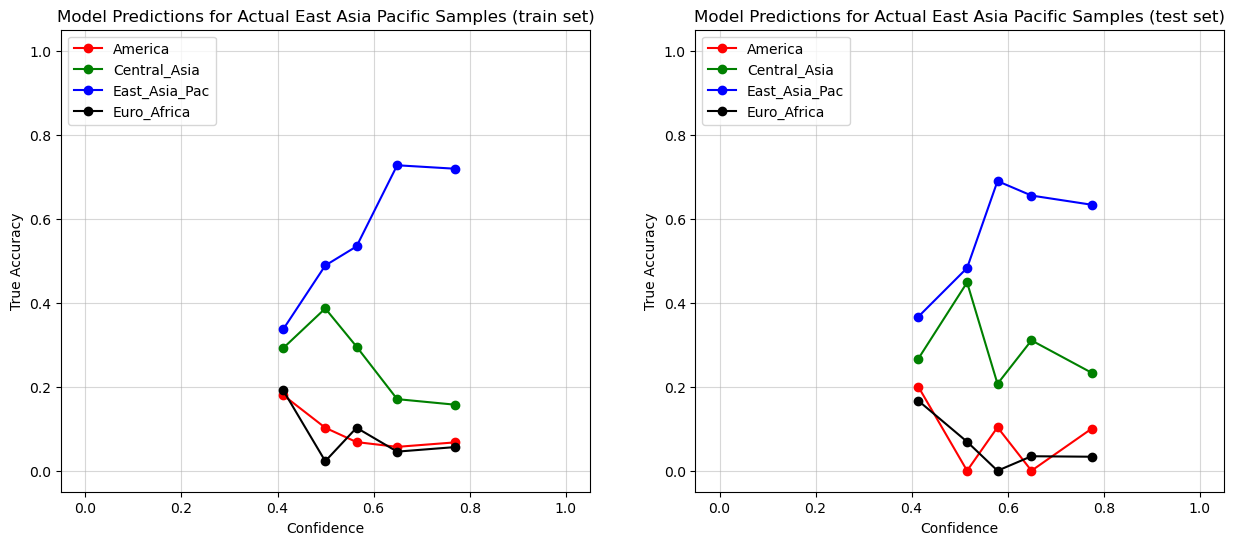

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
colors = ['red', 'green', 'blue', 'black']
for j, a in zip(range(2), ["train", "test"]):
    for l,c in zip(labels, colors):
        proba = locals()[f"y_{a}_proba"]
        pred  = locals()[f"y_{a}_pred"]
        true  = locals()[f"y_{a}"]
    
        subset = (true == "East_Asia_Pac")
        
        confidences = np.max(proba[subset], axis=1)
        accuracies = (pred[subset] == l).astype(int)
        n_bins = 5
        percentiles = np.linspace(0.0, 1.0, n_bins + 1)
        try:
            bins = np.quantile(confidences, percentiles)
            bin_indices = np.digitize(confidences, bins) - 1
            bin_indices[bin_indices == n_bins] = n_bins - 1
            
            bin_accuracies = []
            bin_confidences = []
            bin_percentages = []
            
            # Výpočet priemernej istoty, presnosti a percenta dát pre každý bin
            for i in range(n_bins):
                mask = (bin_indices == i)
                if np.sum(mask) > 0: # Ak sú v bine nejaké dáta
                    bin_accuracies.append(np.mean(accuracies[mask]))
                    bin_confidences.append(np.mean(confidences[mask]))
                    bin_percentages.append((np.sum(mask) / len(confidences)) * 100)
        
            # Tvoja krivka modelu
            ax[j].plot(bin_confidences, bin_accuracies, marker = 'o', linestyle = '-', color=c, label=l)
        except Exception as e:
            continue
        
    
    
    ax[j].set_xlabel("Confidence")
    ax[j].set_ylabel("True Accuracy")
    ax[j].set_title(f"Model Predictions for Actual East Asia Pacific Samples ({a} set)")
    ax[j].legend(loc="upper left")
    ax[j].grid(True, alpha=0.5)
    ax[j].set_xlim([-0.05, 1.05])
    ax[j].set_ylim([-0.05, 1.05])

plt.show()

# XGBoost

## Parameters fitting

In [50]:
def objective(trial):
    param = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
        "eta": trial.suggest_float("eta", 0.01, 0.1),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 5),
        "max_depth": trial.suggest_int("max_depth", 2, 8),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0)
    }

    model = xgb.XGBClassifier(
        **param,
    )


    scoring = {
        'brier': 'neg_brier_score',
        'wf1': 'f1_weighted'
    }
    
    cv_results = cross_validate(model, X_train[col_names], y_train_encoded, params={'sample_weight': sample_weights}, cv = 5, scoring=scoring, return_train_score = True)
    brier_test =  cv_results['test_brier'].mean()
    brier_train = cv_results["train_brier"].mean()
    f1_train = cv_results['train_wf1'].mean()
    f1_test = cv_results['test_wf1'].mean()

    trial.set_user_attr("brier_test", brier_test)
    trial.set_user_attr("brier_train", brier_train)
    trial.set_user_attr("f1_train", f1_train)
    trial.set_user_attr("f1_test", f1_test)
    
    
    score = brier_test - 1 * (brier_train-brier_test)
    return score

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify = y, random_state = 7736)
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)
labels = le.classes_
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

In [52]:
study = optuna.create_study(study_name = "xgboost_study", direction = "maximize")
study.optimize(objective, n_trials = 250, show_progress_bar = True, n_jobs = 1)


[I 2026-04-24 16:22:00,487] A new study created in memory with name: xgboost_study


  0%|          | 0/250 [00:00<?, ?it/s]

[I 2026-04-24 16:22:03,112] Trial 0 finished with value: -0.7290209642308474 and parameters: {'n_estimators': 132, 'eta': 0.048819303144372925, 'gamma': 0.4058822494163594, 'reg_lambda': 3.565074821936573, 'max_depth': 6, 'min_child_weight': 11, 'subsample': 0.6497643396295029, 'colsample_bytree': 0.9709178098308182}. Best is trial 0 with value: -0.7290209642308474.
[W 2026-04-24 16:22:05,533] Trial 1 failed with parameters: {'n_estimators': 809, 'eta': 0.08630046825646093, 'gamma': 3.659155307482317, 'reg_lambda': 4.505544233293406, 'max_depth': 8, 'min_child_weight': 6, 'subsample': 0.9539858723437146, 'colsample_bytree': 0.855261242768335} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "C:\Users\matej\anaconda3\envs\test_env\Lib\site-packages\optuna\study\_optimize.py", line 205, in _run_trial
    value_or_values = func(trial)
  File "C:\Users\matej\AppData\Local\Temp\ipykernel_21036\3578865613.py", line 23, in objective
    cv_results

KeyboardInterrupt: 

In [22]:
best_params = study.best_params
best_params

{'n_estimators': 211,
 'eta': 0.038741570723655985,
 'gamma': 4.998847340927335,
 'reg_lambda': 3.316876517397734,
 'max_depth': 2,
 'min_child_weight': 19,
 'subsample': 0.6350672580897165,
 'colsample_bytree': 0.8466734018456014}

In [23]:
df = study.trials_dataframe()
print(df[['value', 'user_attrs_brier_train', 'user_attrs_brier_test', 'user_attrs_f1_train', 'user_attrs_f1_test']])

        value  user_attrs_brier_train  user_attrs_brier_test  \
0   -0.882249               -0.160118              -0.521184   
1   -0.628963               -0.357784              -0.493373   
2   -0.619330               -0.368830              -0.494080   
3   -0.575559               -0.411567              -0.493563   
4   -0.872154               -0.126512              -0.499333   
5   -0.952185               -0.098143              -0.525164   
6   -0.732750               -0.263323              -0.498036   
7   -0.582216               -0.401765              -0.491991   
8   -0.601451               -0.506857              -0.554154   
9   -0.774278               -0.253715              -0.513997   
10  -0.569099               -0.429077              -0.499088   
11  -0.567835               -0.432372              -0.500103   
12  -0.568246               -0.431475              -0.499861   
13  -0.568941               -0.434130              -0.501535   
14  -0.611827               -0.368176   

In [85]:
model = xgb.XGBClassifier(
    n_estimators= 211,              
    eta= 0.038741570723655985,
    gamma = 4.998847340927335,
    reg_lambda =3.316876517397734,
    max_depth = 2,
    min_child_weight= 19,           
    subsample =0.63506725808971654,
    colsample_bytree=0.8466734018456014
)
scoring = {
        'brier': 'neg_brier_score',
        'wf1': 'f1_weighted'
    }
cv_results = cross_validate(model, X_train[col_names], y_train_encoded, params={'sample_weight': sample_weights}, cv = 5, scoring=scoring, return_train_score = True)
cv_results

{'fit_time': array([0.27739143, 0.2636466 , 0.25843334, 0.3123765 , 0.31352782]),
 'score_time': array([0.0152297 , 0.01488686, 0.0143888 , 0.01487112, 0.01490188]),
 'test_brier': array([-0.48136653, -0.50192856, -0.48818303, -0.50936284, -0.53344801]),
 'train_brier': array([-0.45633268, -0.45177422, -0.45716196, -0.45053423, -0.44062955]),
 'test_wf1': array([0.67786302, 0.62768398, 0.67033134, 0.62171606, 0.6062682 ]),
 'train_wf1': array([0.68500247, 0.69972433, 0.68306478, 0.69655992, 0.71136977])}

In [89]:
cv_results["test_brier"].mean()

np.float64(-0.5028577939422199)

## Model

In [76]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify = y, random_state = num)
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)
labels = le.classes_
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

In [77]:
model = xgb.XGBClassifier(
    n_estimators= 211,              
    eta= 0.038741570723655985,
    gamma = 4.998847340927335,
    reg_lambda =3.316876517397734,
    max_depth = 2,
    min_child_weight= 19,           
    subsample =0.63506725808971654,
    colsample_bytree=0.8466734018456014
)

In [78]:
model.fit(X_train[col_names], y_train_encoded, sample_weight = sample_weights)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8466734018456014
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [79]:
y_train_pred = model.predict(X_train[col_names])
y_train_pred = le.inverse_transform(y_train_pred)
y_train_proba = model.predict_proba(X_train[col_names])

y_test_pred = model.predict(X_test[col_names])
y_test_pred = le.inverse_transform(y_test_pred)
y_test_proba = model.predict_proba(X_test[col_names])

C:\Users\matej\anaconda3\envs\test_env\Lib\site-packages\xgboost\plotting.py:267: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


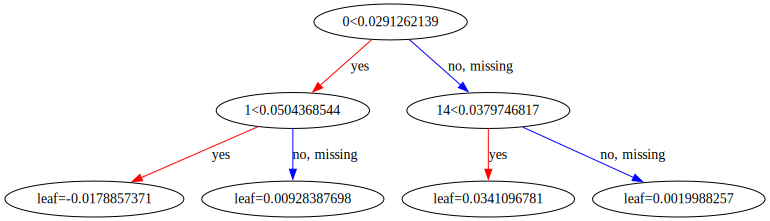

In [80]:
visual = xgb.to_graphviz(model, num_trees=4)
visual

## Classification metrics

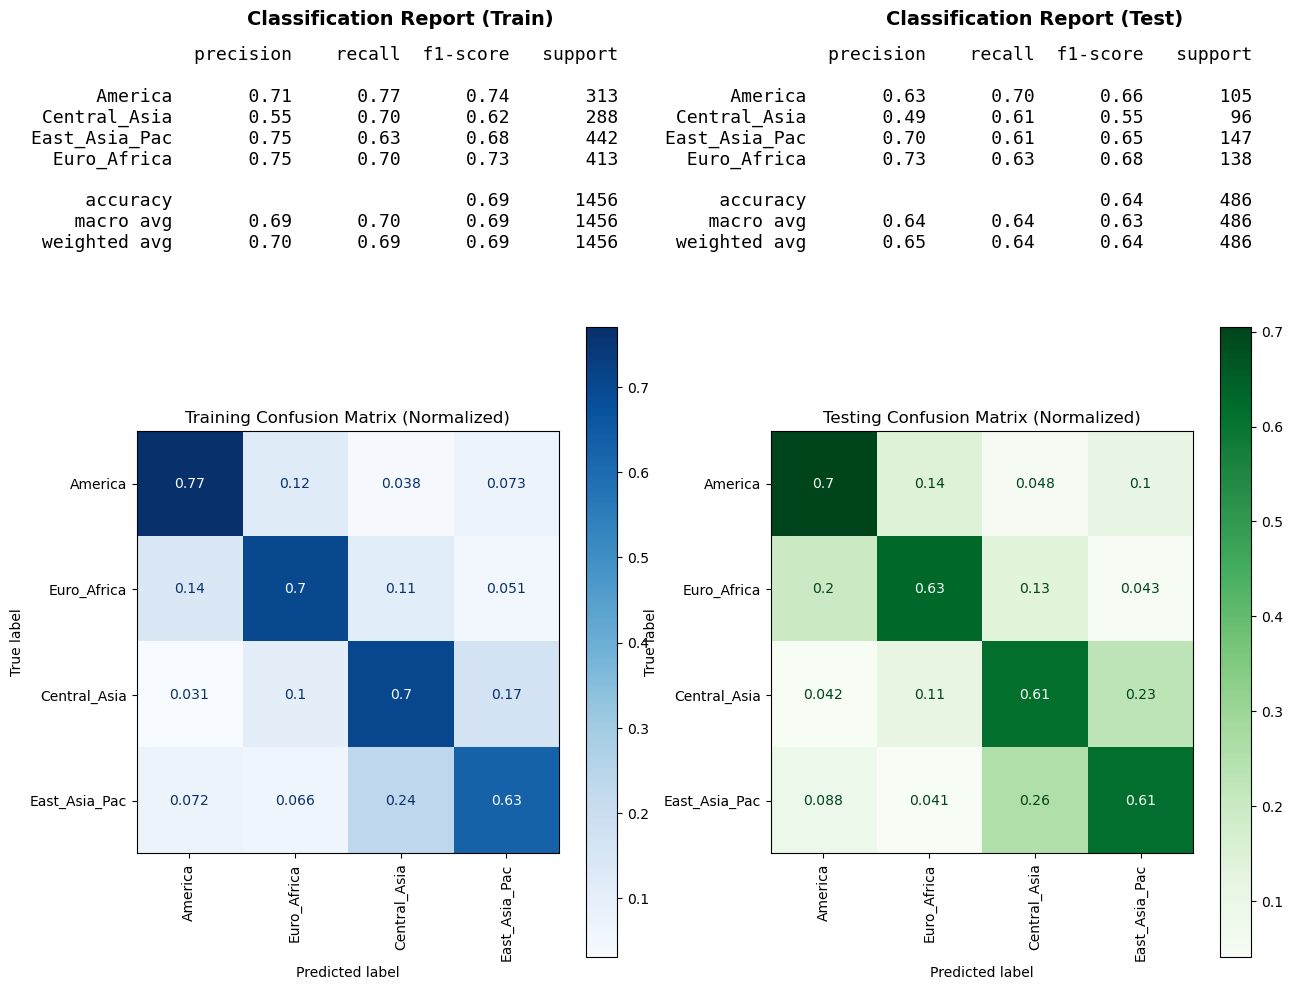

In [45]:
target_names = ["America", "Euro_Africa", "Central_Asia", "East_Asia_Pac"]
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 12), 
                         gridspec_kw={'height_ratios': [0.5, 1.5]})

#Train classification report
axes[0, 0].text(-0.2, 0.4, classification_report(y_train, y_train_pred, target_names = labels), 
                fontsize=13, family='monospace', va='center')
axes[0, 0].set_title("Classification Report (Train)", fontsize=14, fontweight='bold')
axes[0, 0].axis('off') 

#Test classification report
axes[0, 1].text(-0.2, 0.4, classification_report(y_test, y_test_pred, target_names = labels), 
                fontsize=13, family='monospace', va='center')
axes[0, 1].set_title("Classification Report (Test)", fontsize=14, fontweight='bold')
axes[0, 1].axis('off') 

# Train Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_train, y_train_pred, 
    ax=axes[1, 0], cmap='Blues', normalize='true',
    labels = target_names
)
axes[1, 0].set_title("Training Confusion Matrix (Normalized)")
axes[1, 0].tick_params(axis='x', rotation=90)

# Test Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_pred, 
    ax=axes[1, 1], cmap='Greens', normalize='true',
    labels = target_names
)
axes[1, 1].set_title("Testing Confusion Matrix (Normalized)")
axes[1, 1].tick_params(axis='x', rotation=90)

plt.show()

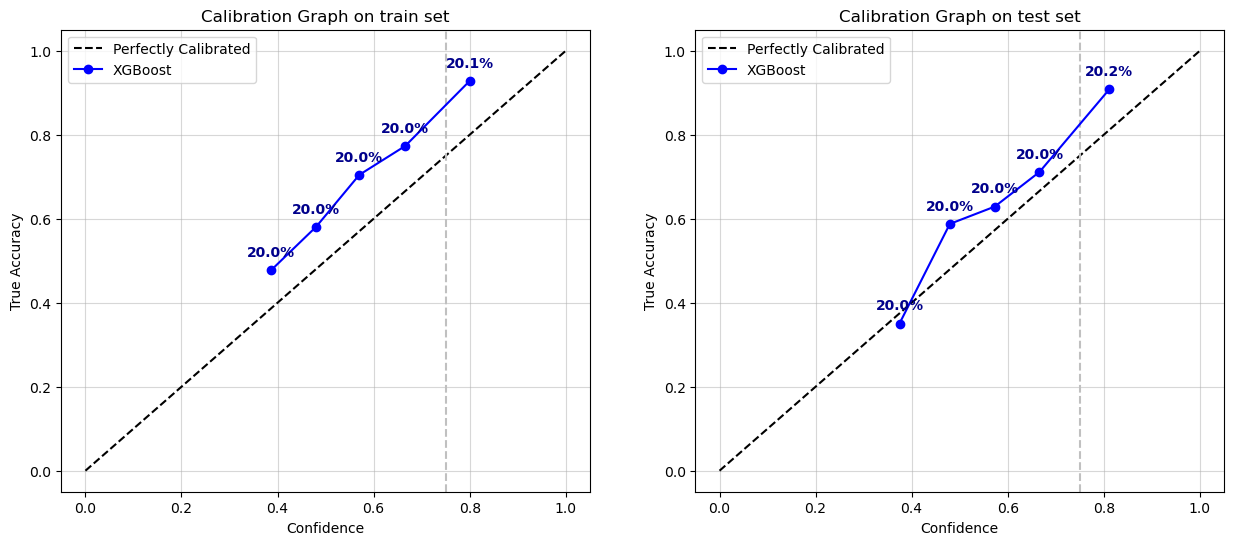

In [49]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

for j, l in zip(range(2), ["train", "test"]):
    ax[j].plot([0, 1], [0, 1], "k--", label="Perfectly Calibrated")
    ax[j].plot([0.75, 0.75], [-0.05, 1.05], "--", color = "#C0C0C0")

    proba = locals()[f"y_{l}_proba"]
    pred  = locals()[f"y_{l}_pred"]
    true  = locals()[f"y_{l}"]
    
    confidences = np.max(proba, axis=1)
    accuracies = (pred == true).astype(int)
    n_bins = 5
    percentiles = np.linspace(0.0, 1.0, n_bins + 1)
    bins = np.quantile(confidences, percentiles)
    bin_indices = np.digitize(confidences, bins) - 1
    bin_indices[bin_indices == n_bins] = n_bins - 1
    
    bin_accuracies = []
    bin_confidences = []
    bin_percentages = []
    
    for i in range(n_bins):
        mask = (bin_indices == i)
        if np.sum(mask) > 0: # Ak sú v bine nejaké dáta
            bin_accuracies.append(np.mean(accuracies[mask]))
            bin_confidences.append(np.mean(confidences[mask]))
            bin_percentages.append((np.sum(mask) / len(confidences)) * 100)
    
    ax[j].plot(bin_confidences, bin_accuracies, "bo-", label="XGBoost")
    
    for b, v, perc in zip(bin_confidences, bin_accuracies, bin_percentages):
        ax[j].annotate(f"{perc:.1f}%", 
                     (b, v), 
                     textcoords="offset points", 
                     xytext=(0, 10), 
                     ha='center',
                     fontsize=10,
                     color="darkblue",
                     fontweight="bold")
    
    ax[j].set_xlabel("Confidence")
    ax[j].set_ylabel("True Accuracy")
    ax[j].set_title(f"Calibration Graph on {l} set")
    ax[j].legend(loc="upper left")
    ax[j].grid(True, alpha=0.5)
    ax[j].set_xlim([-0.05, 1.05])
    ax[j].set_ylim([-0.05, 1.05])

plt.show()

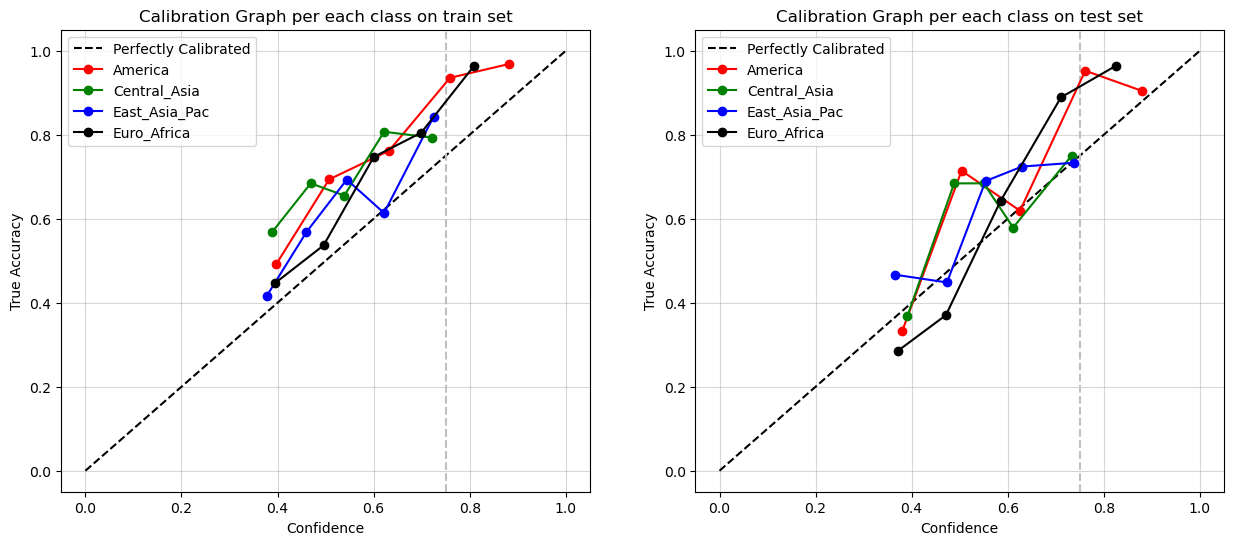

In [47]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
colors = ['red', 'green', 'blue', 'black']

for j, a in zip(range(2), ["train", "test"]):
    ax[j].plot([0, 1], [0, 1], "k--", label="Perfectly Calibrated")
    ax[j].plot([0.75, 0.75], [-0.05, 1.05], "--", color = "#C0C0C0")
    for l, c in zip(labels, colors):
        proba = locals()[f"y_{a}_proba"]
        pred  = locals()[f"y_{a}_pred"]
        true  = locals()[f"y_{a}"]
    
        subset = (true == l)
        
        confidences = np.max(proba[subset], axis=1)
        accuracies = (pred[subset] == true[subset]).astype(int)
        n_bins = 5
        percentiles = np.linspace(0.0, 1.0, n_bins + 1)
        bins = np.quantile(confidences, percentiles)
        bin_indices = np.digitize(confidences, bins) - 1
        bin_indices[bin_indices == n_bins] = n_bins - 1
        
        bin_accuracies = []
        bin_confidences = []
        bin_percentages = []
        
        for i in range(n_bins):
            mask = (bin_indices == i)
            if np.sum(mask) > 0: # Ak sú v bine nejaké dáta
                bin_accuracies.append(np.mean(accuracies[mask]))
                bin_confidences.append(np.mean(confidences[mask]))
                bin_percentages.append((np.sum(mask) / len(confidences)) * 100)
    
        ax[j].plot(bin_confidences, bin_accuracies, marker = 'o', linestyle = '-', color=c, label=l)
    
    
    
    ax[j].set_xlabel("Confidence")
    ax[j].set_ylabel("True Accuracy")
    ax[j].set_title(f"Calibration Graph per each class on {a} set")
    ax[j].legend(loc="upper left")
    ax[j].grid(True, alpha=0.5)
    ax[j].set_xlim([-0.05, 1.05])
    ax[j].set_ylim([-0.05, 1.05])

plt.show()

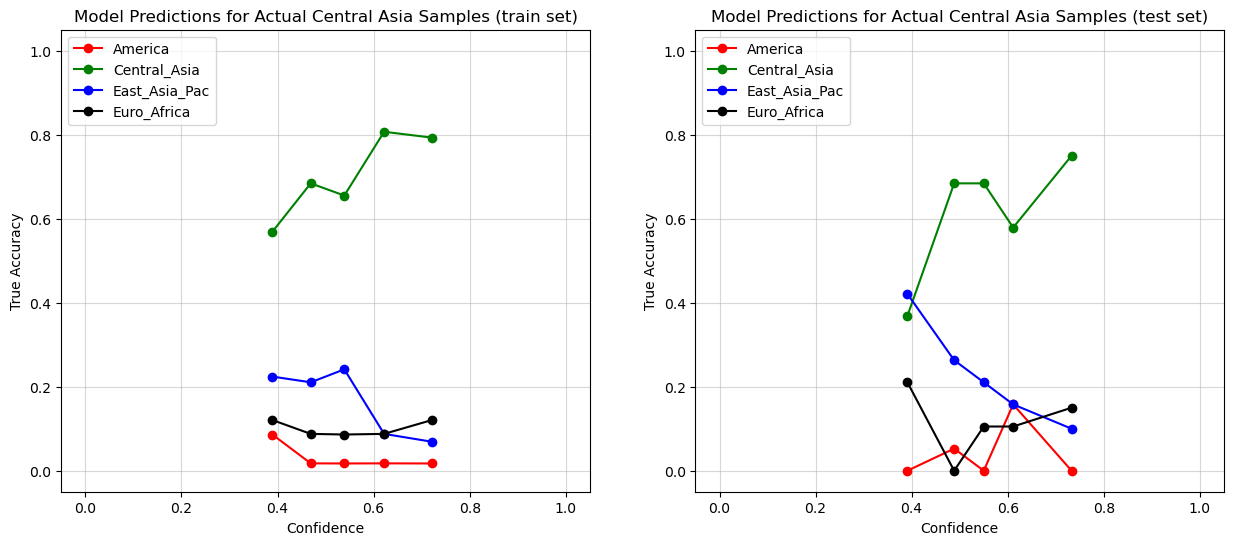

In [48]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
colors = ['red', 'green', 'blue', 'black']
for j, a in zip(range(2), ["train", "test"]):
    for l,c in zip(labels, colors):
        proba = locals()[f"y_{a}_proba"]
        pred  = locals()[f"y_{a}_pred"]
        true  = locals()[f"y_{a}"]
    
        subset = (true == "Central_Asia")
        
        confidences = np.max(proba[subset], axis=1)
        accuracies = (pred[subset] == l).astype(int)
        n_bins = 5
        percentiles = np.linspace(0.0, 1.0, n_bins + 1)
        try:
            bins = np.quantile(confidences, percentiles)
            bin_indices = np.digitize(confidences, bins) - 1
            bin_indices[bin_indices == n_bins] = n_bins - 1
            
            bin_accuracies = []
            bin_confidences = []
            bin_percentages = []
            
            # Výpočet priemernej istoty, presnosti a percenta dát pre každý bin
            for i in range(n_bins):
                mask = (bin_indices == i)
                if np.sum(mask) > 0: # Ak sú v bine nejaké dáta
                    bin_accuracies.append(np.mean(accuracies[mask]))
                    bin_confidences.append(np.mean(confidences[mask]))
                    bin_percentages.append((np.sum(mask) / len(confidences)) * 100)
        
            # Tvoja krivka modelu
            ax[j].plot(bin_confidences, bin_accuracies, marker = 'o', linestyle = '-', color=c, label=l)
        except Exception as e:
            continue
        
    
    
    ax[j].set_xlabel("Confidence")
    ax[j].set_ylabel("True Accuracy")
    ax[j].set_title(f"Model Predictions for Actual Central Asia Samples ({a} set)")
    ax[j].legend(loc="upper left")
    ax[j].grid(True, alpha=0.5)
    ax[j].set_xlim([-0.05, 1.05])
    ax[j].set_ylim([-0.05, 1.05])

plt.show()

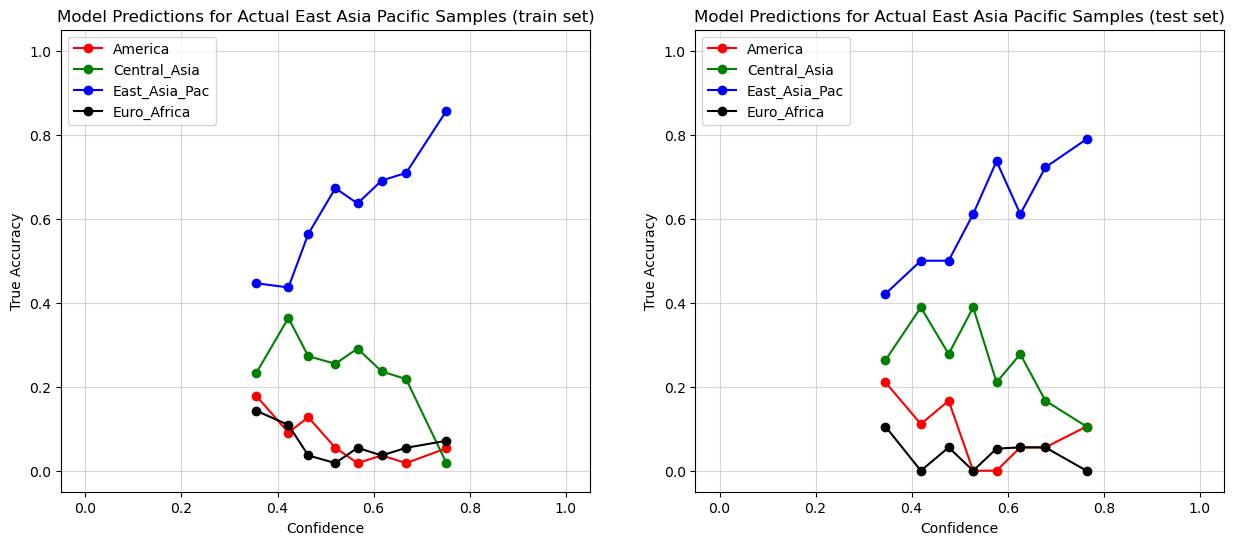

In [33]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
colors = ['red', 'green', 'blue', 'black']
for j, a in zip(range(2), ["train", "test"]):
    for l,c in zip(labels, colors):
        proba = locals()[f"y_{a}_proba"]
        pred  = locals()[f"y_{a}_pred"]
        true  = locals()[f"y_{a}"]
    
        subset = (true == "East_Asia_Pac")
        
        confidences = np.max(proba[subset], axis=1)
        accuracies = (pred[subset] == l).astype(int)
        n_bins = 8
        percentiles = np.linspace(0.0, 1.0, n_bins + 1)
        try:
            bins = np.quantile(confidences, percentiles)
            bin_indices = np.digitize(confidences, bins) - 1
            bin_indices[bin_indices == n_bins] = n_bins - 1
            
            bin_accuracies = []
            bin_confidences = []
            bin_percentages = []
            
            # Výpočet priemernej istoty, presnosti a percenta dát pre každý bin
            for i in range(n_bins):
                mask = (bin_indices == i)
                if np.sum(mask) > 0: # Ak sú v bine nejaké dáta
                    bin_accuracies.append(np.mean(accuracies[mask]))
                    bin_confidences.append(np.mean(confidences[mask]))
                    bin_percentages.append((np.sum(mask) / len(confidences)) * 100)
        
            # Tvoja krivka modelu
            ax[j].plot(bin_confidences, bin_accuracies, marker = 'o', linestyle = '-', color=c, label=l)
        except Exception as e:
            continue
        
    
    
    ax[j].set_xlabel("Confidence")
    ax[j].set_ylabel("True Accuracy")
    ax[j].set_title(f"Model Predictions for Actual East Asia Pacific Samples ({a} set)")
    ax[j].legend(loc="upper left")
    ax[j].grid(True, alpha=0.5)
    ax[j].set_xlim([-0.05, 1.05])
    ax[j].set_ylim([-0.05, 1.05])

plt.show()